# Practical Statistics for Data Scientists (Python + R)
# Chapter 1. Exploratory Data Analysis
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

## Loading the rpy2 extension in a notebook with the Python kernel

In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

# Loading the extension without noise
%load_ext rpy2.ipython

sys.stderr = stderr_original  # Restore silently

In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)

## Import packages

### Import Python packages

In [3]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import seaborn as sns
import matplotlib.pylab as plt

In [4]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages

In [5]:
%%R
Sys.setlocale("LC_ALL", "English")
# Install missing packages if needed
packages <- c("dplyr", "tidyr", "ggplot2", "corrplot", "gmodels", "matrixStats", "hexbin")
installed <- rownames(installed.packages())
to_install <- packages[!packages %in% installed]
if (length(to_install) > 0) {
  install.packages(to_install, repos = 'https://cloud.r-project.org/')
}

# Load them all
library(dplyr)
library(tidyr)
library(ggplot2)
library(corrplot)
library(gmodels)
library(matrixStats)
library(hexbin)


Dolaczanie pakietu: 'dplyr'

Nastepujace obiekty zostaly zakryte z 'package:stats':

    filter, lag

Nastepujace obiekty zostaly zakryte z 'package:base':

    intersect, setdiff, setequal, union

corrplot 0.95 loaded

Dolaczanie pakietu: 'matrixStats'

Nastepujacy obiekt zostal zakryty z 'package:dplyr':

    count

In addition: Warning messages:
1: pakiet 'corrplot' zostal zbudowany w wersji R 4.5.3 
2: pakiet 'gmodels' zostal zbudowany w wersji R 4.5.3 
3: pakiet 'matrixStats' zostal zbudowany w wersji R 4.5.3 
4: pakiet 'hexbin' zostal zbudowany w wersji R 4.5.3 


## Defining data paths
Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

### Data Assignment - Python

In [6]:
AIRLINE_STATS_CSV = DATA / 'airline_stats.csv'
KC_TAX_CSV = DATA / 'kc_tax.csv.gz'
LC_LOANS_CSV = DATA / 'lc_loans.csv'
AIRPORT_DELAYS_CSV = DATA / 'dfw_airline.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
STATE_CSV = DATA / 'state.csv'

### Data Assignment - R

In [7]:
%%R 
PSDS_PATH <- file.path(dirname(dirname(getwd())))
 
state <- read.csv(file.path(PSDS_PATH, 'data', 'state.csv'))
dfw <- read.csv(file.path(PSDS_PATH, 'data', 'dfw_airline.csv'))
sp500_px <- read.csv(file.path(PSDS_PATH, 'data', 'sp500_data.csv.gz'), row.names=1)
sp500_sym <- read.csv(file.path(PSDS_PATH, 'data', 'sp500_sectors.csv'), stringsAsFactors = FALSE)
kc_tax <- read.csv(file.path(PSDS_PATH, 'data', 'kc_tax.csv.gz'))
lc_loans <- read.csv(file.path(PSDS_PATH, 'data', 'lc_loans.csv'))
airline_stats <- read.csv(file.path(PSDS_PATH, 'data', 'airline_stats.csv'), stringsAsFactors = FALSE)
airline_stats$airline <- ordered(airline_stats$airline, 
                                 levels=c('Alaska', 'American', 'Jet Blue', 'Delta', 'United', 'Southwest'))

### Summary: Defining data paths

| Operation | Python | R | Notes |
|---|---|---|---|
| Base path setup | `Path(...)` / explicit strings | direct path strings in `read.csv()` | Both point to the same chapter datasets. |
| Dataset loading | `pd.read_csv(...)` | `read.csv(...)` | Equivalent import step with language-specific defaults. |
| Basic preprocessing | pandas column transforms | base R column transforms | Both align units before analysis. |

Python makes path handling and transformations explicit through objects, while R keeps data import and quick preprocessing concise.

# Estimates of Location
## Example: Location Estimates of Population and Murder Rates

### Python

In [8]:
# Table 1-2
state = pd.read_csv(STATE_CSV)
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


Compute the mean, trimmed mean, and median for Population. For `mean` and `median` we can use the _pandas_ methods of the data frame. The trimmed mean requires the `trim_mean` function in _scipy.stats_.

In [9]:
state = pd.read_csv(STATE_CSV)
print(state['Population'].mean())

6162876.3


In [10]:
print(trim_mean(state['Population'], 0.1))

4783697.125


In [11]:
print(state['Population'].median())

4436369.5


Weighted mean is available with numpy. For weighted median, we can use the specialised package `wquantiles` (https://pypi.org/project/wquantiles/).

In [12]:
print(state['Murder.Rate'].mean())

4.066


In [13]:
print(np.average(state['Murder.Rate'], weights=state['Population']))

4.445833981123393


In [14]:
print(wquantiles.median(state['Murder.Rate'], weights=state['Population']))

4.4


### R
R shows the same location estimators (mean, trimmed mean, median, and weighted variants) using base functions and `matrixStats`.

In [15]:
%%R
# Table 1-2
state_asc <- state
state_asc[['Population']] <- formatC(state_asc[['Population']], format='d', digits=0, big.mark=',')
state_asc[1:8,]

        State Population Murder.Rate Abbreviation
1     Alabama  4,779,736         5.7           AL
2      Alaska    710,231         5.6           AK
3     Arizona  6,392,017         4.7           AZ
4    Arkansas  2,915,918         5.6           AR
5  California 37,253,956         4.4           CA
6    Colorado  5,029,196         2.8           CO
7 Connecticut  3,574,097         2.4           CT
8    Delaware    897,934         5.8           DE


In [16]:
%%R
results <- c(
    mean(state[['Population']]),
    mean(state[['Population']], trim=0.1),
    median(state[['Population']])
)
print(results)

[1] 6162876 4783697 4436370


In [17]:
%%R
library('matrixStats')
results <- c(
    weighted.mean(state[['Murder.Rate']], w=state[['Population']]),
    weightedMedian(state[['Murder.Rate']], w=state[['Population']])
)
print(results)

[1] 4.445834 4.400000


### Summary: Estimates of Location

| Operation | Python | R | Notes |
|---|---|---|---|
| Mean, median | `Series.mean()`, `Series.median()` | `mean()`, `median()` | Both approaches are direct and readable. |
| Trimmed mean | `scipy.stats.trim_mean()` | `mean(trim=...)` | In R, trimming is built into `mean`. |
| Weighted measures | `np.average()`, `wquantiles.median()` | `weighted.mean()`, `matrixStats::weightedMedian()` | Python more often combines multiple packages for a complete set of measures. |

Python is more object-oriented around `pandas` columns, while R more often uses concise statistical functions. In practice, both languages provide a comparable set of measures with different API ergonomics.


# Estimates of Variability

### Python

In [18]:
# Table 1-2
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


Standard deviation

In [19]:
print(state['Population'].std())

6848235.347401142


Interquartile range is calculated as the difference of the 75% and 25% quantile.

In [20]:
print(state['Population'].quantile(0.75) - state['Population'].quantile(0.25))

4847308.0


Median absolute deviation from the median can be calculated with a method in _statsmodels_

In [21]:
print(robust.scale.mad(state['Population']))
print(abs(state['Population'] - state['Population'].median()).median() / 0.6744897501960817)

3849876.1459979336
3849876.1459979336


### R
R computes variability measures analogous to Python: standard deviation, IQR, and MAD.

In [22]:
%%R
results <- c(
    sd(state[['Population']]),
    IQR(state[['Population']]),
    mad(state[['Population']])
)
print(results)

[1] 6848235 4847308 3849870


### Summary: Estimates of Variability

| Operation | Python | R | Notes |
|---|---|---|---|
| Standard deviation | `Series.std()` | `sd()` | Same computational semantics. |
| IQR | `quantile(0.75)-quantile(0.25)` | `IQR()` | R has a convenient dedicated function. |
| MAD | `statsmodels.robust.scale.mad()` | `mad()` | Python usually needs an additional package. |

Python offers high control through composable operations, while R provides more built-in statistical shortcuts. The difference is mostly practical, not conceptual.


## Percentiles and Boxplots

### Python
_Pandas_ has the `quantile` method for data frames.

In [23]:
print(state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


In [24]:
# Table 1.4
percentages = [0.05, 0.25, 0.5, 0.75, 0.95]
df = pd.DataFrame(state['Murder.Rate'].quantile(percentages))
df.index = [f'{p * 100}%' for p in percentages]
print(df.transpose())

             5.0%  25.0%  50.0%  75.0%  95.0%
Murder.Rate   1.6  2.425    4.0   5.55   6.51


_Pandas_ provides a number of basic exploratory plots; one of them are boxplots

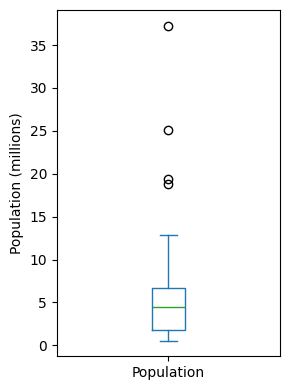

In [25]:
ax = (state['Population']/1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Population (millions)')

plt.tight_layout()
plt.show()

### R
R uses `quantile` and `boxplot` to present percentiles and distribution shape.

In [26]:
%%R
quantile(state[['Murder.Rate']], p=c(.05, .25, .5, .75, .95))

   5%   25%   50%   75%   95% 
1.600 2.425 4.000 5.550 6.510 


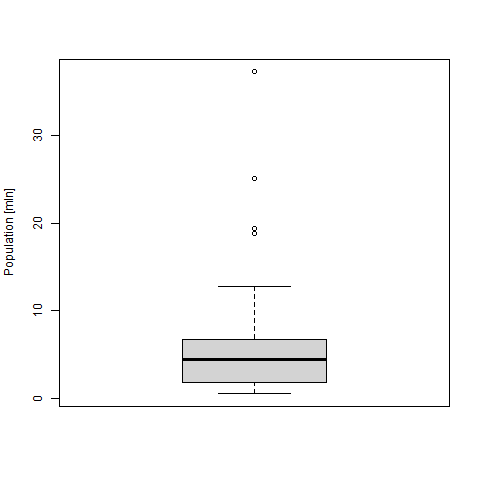

In [27]:
%%R
boxplot(state[['Population']]/1000000, ylab='Population [mln]')

### Summary: Percentiles and Boxplots

| Operation | Python | R | Notes |
|---|---|---|---|
| Percentiles | `Series.quantile([...])` | `quantile(..., p=...)` | Both approaches support a list of levels. |
| Percentile table | `DataFrame(...)` + index formatting | `quantile()` output | Python makes publication-style formatting easy. |
| Boxplot | `Series.plot.box()` | `boxplot()` | Both libraries provide a native boxplot implementation. |

In Python, the usual path is data -> DataFrame -> plot, while in R it is often statistical function -> plotting function. This affects coding style more than interpretation.


## Frequency Table and Histograms

### Python
The `cut` method for _pandas_ data splits the dataset into bins. There are a number of arguments for the method. The following code creates equal sized bins. The method `value_counts` returns a frequency table.

In [28]:
binnedPopulation = pd.cut(state['Population'], 10)
print(binnedPopulation.value_counts())

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64


In [29]:
# Table 1.5
binnedPopulation.name = 'binnedPopulation'
df = pd.concat([state, binnedPopulation], axis=1)
df = df.sort_values(by='Population')

groups = []
for group, subset in df.groupby(by='binnedPopulation', observed=False):
    groups.append({
        'BinRange': group,
        'Count': len(subset),
        'States': ','.join(subset.Abbreviation)
    })
print(pd.DataFrame(groups))

                   BinRange  Count  \
0    (526935.67, 4232659.0]     24   
1    (4232659.0, 7901692.0]     14   
2   (7901692.0, 11570725.0]      6   
3  (11570725.0, 15239758.0]      2   
4  (15239758.0, 18908791.0]      1   
5  (18908791.0, 22577824.0]      1   
6  (22577824.0, 26246857.0]      1   
7  (26246857.0, 29915890.0]      0   
8  (29915890.0, 33584923.0]      0   
9  (33584923.0, 37253956.0]      1   

                                              States  
0  WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N...  
1          KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA  
2                                  VA,NJ,NC,GA,MI,OH  
3                                              PA,IL  
4                                                 FL  
5                                                 NY  
6                                                 TX  
7                                                     
8                                                     
9                              

_Pandas_ also supports histograms for exploratory data analysis.

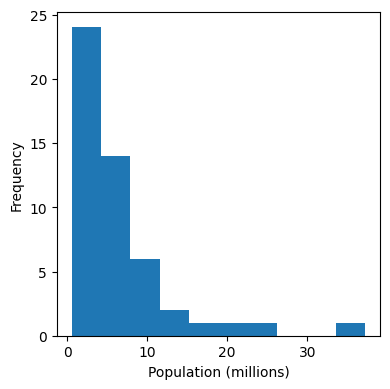

In [30]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')

plt.tight_layout()
plt.show()

### R
R creates bins with `cut`, frequency tables with `table`, and histograms with `hist`.

In [31]:
%%R
breaks <- seq(from=min(state[['Population']]), 
              to=max(state[['Population']]), length=11)
pop_freq <- cut(state[['Population']], breaks=breaks, 
                right=TRUE, include.lowest=TRUE)
state['PopFreq'] <- pop_freq
table(pop_freq)

pop_freq
[5.64e+05,4.23e+06]  (4.23e+06,7.9e+06]  (7.9e+06,1.16e+07] (1.16e+07,1.52e+07] 
                 24                  14                   6                   2 
(1.52e+07,1.89e+07] (1.89e+07,2.26e+07] (2.26e+07,2.62e+07] (2.62e+07,2.99e+07] 
                  1                   1                   1                   0 
(2.99e+07,3.36e+07] (3.36e+07,3.73e+07] 
                  0                   1 


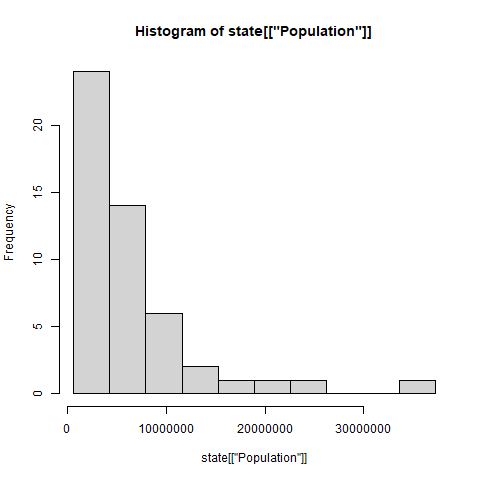

In [32]:
%%R
options(scipen=5)
hist(state[['Population']], breaks=breaks)

### Summary: Frequency Table and Histograms

| Operation | Python | R | Notes |
|---|---|---|---|
| Binning | `pd.cut()` | `cut()` | Functionally very similar. |
| Frequency table | `value_counts()` | `table()` | R offers a simple, base contingency table function. |
| Histogram | `plot.hist()` | `hist()` | Both are standard EDA tools. |

Python integrates frequency tables better with downstream `DataFrame` transformations, while R is very concise for univariate analysis. In both cases, bin design strongly affects conclusions.


## Density Estimates


### Python
Density is an alternative to histograms that can provide more insight into the distribution of the data points. Use the argument `bw_method` to control the smoothness of the density curve.

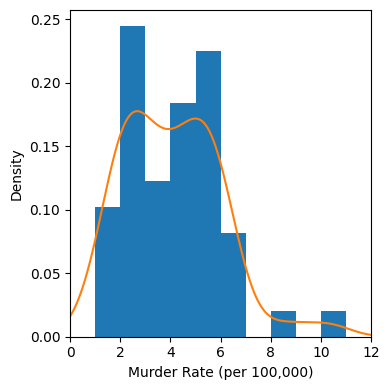

In [33]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], 
                                    bins=range(1,12), figsize=(4, 4))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')

plt.tight_layout()
plt.show()

### R
Density is an alternative to histograms that can provide more insight into the distribution of the data points. 

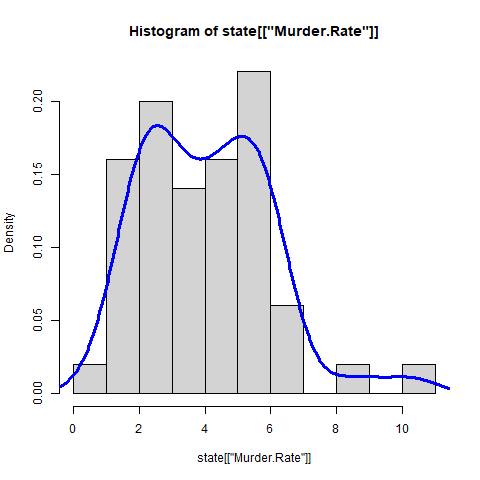

In [34]:
%%R
hist(state[['Murder.Rate']], freq=FALSE )
lines(density(state[['Murder.Rate']]), lwd=3, col='blue')

### Summary: Density Estimates

| Operation | Python | R | Notes |
|---|---|---|---|
| Density histogram | `plot.hist(density=True)` | `hist(..., freq=FALSE)` | Equivalent scaling setup. |
| Density curve | `plot.density()` | `lines(density(...))` | R requires explicitly adding the layer. |
| Smoothing control | `bw_method` | `density()` parameters | Both languages support smoothness tuning. |

Python promotes a layered style through object methods, while base R classically adds elements to an existing plot. Both styles support quick shape detection.


# Exploring Binary and Categorical Data

### Python

In [35]:
# Table 1-6
dfw = pd.read_csv(AIRPORT_DELAYS_CSV)
print(100 * dfw / dfw.values.sum())

     Carrier        ATC   Weather  Security    Inbound
0  23.022989  30.400781  4.025214  0.122937  42.428079


_Pandas_ also supports bar charts for displaying a single categorical variable.

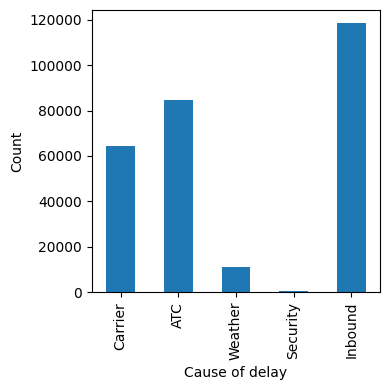

In [36]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### R
R presents categorical structure with a simple bar plot and appropriate scaling.

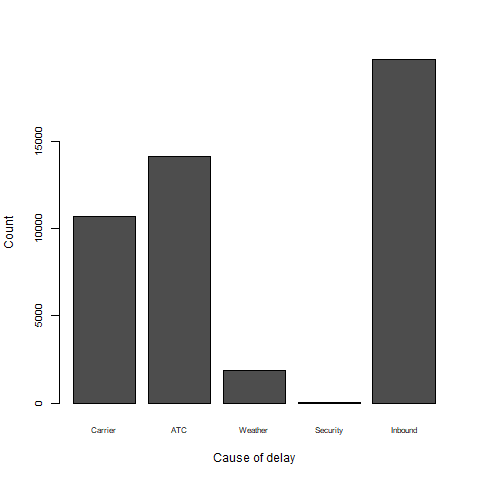

In [37]:
%%R
barplot(as.matrix(dfw) / 6, cex.axis=0.8, cex.names=0.7, 
        xlab='Cause of delay', ylab='Count')

### Summary: Exploring Binary and Categorical Data

| Operation | Python | R | Notes |
|---|---|---|---|
| Percentage shares | `100 * dfw / dfw.values.sum()` | scaling in `barplot(...)` | Python more often computes proportions explicitly before plotting. |
| Bar plot | `plot.bar()` | `barplot()` | Both workflows are short and readable. |
| Axis labels | `set_xlabel()`, `set_ylabel()` | `xlab`, `ylab` | R commonly sets these directly in function arguments. |

In Python, data transformation and visualization are often separated, whereas in R they are often combined in the plotting call. This leads to different code-organization preferences.


# Correlation


### Python
First read the required datasets

In [38]:
sp500_sym = pd.read_csv(SP500_SECTORS_CSV)
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)

In [39]:
# Table 1-7
# Determine telecommunications symbols
telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']

# Filter data for dates July 2012 through June 2015
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
print(telecom.corr())

             T       CTL       FTR        VZ      LVLT
T     1.000000  0.474683  0.327767  0.677612  0.278626
CTL   0.474683  1.000000  0.419757  0.416604  0.286665
FTR   0.327767  0.419757  1.000000  0.287386  0.260068
VZ    0.677612  0.416604  0.287386  1.000000  0.242199
LVLT  0.278626  0.286665  0.260068  0.242199  1.000000


Next we focus on funds traded on major exchanges (sector == 'etf'). 

In [40]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01', 
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
print(etfs.head())

                 XLI       QQQ       SPY       DIA       GLD    VXX       USO  \
2012-07-02 -0.376098  0.096313  0.028223 -0.242796  0.419998 -10.40  0.000000   
2012-07-03  0.376099  0.481576  0.874936  0.728405  0.490006  -3.52  0.250000   
2012-07-05  0.150440  0.096313 -0.103487  0.149420  0.239991   6.56 -0.070000   
2012-07-06 -0.141040 -0.491201  0.018819 -0.205449 -0.519989  -8.80 -0.180000   
2012-07-09  0.244465 -0.048160 -0.056445 -0.168094  0.429992  -0.48  0.459999   

                 IWM       XLE       XLY       XLU       XLB       XTL  \
2012-07-02  0.534641  0.028186  0.095759  0.098311 -0.093713  0.019076   
2012-07-03  0.926067  0.995942  0.000000 -0.044686  0.337373  0.000000   
2012-07-05 -0.171848 -0.460387  0.306431 -0.151938  0.103086  0.019072   
2012-07-06 -0.229128  0.206706  0.153214  0.080437  0.018744 -0.429213   
2012-07-09 -0.190939 -0.234892 -0.201098 -0.035751 -0.168687  0.000000   

                 XLV       XLP       XLF       XLK  
2012-07-02 -0.0

Due to the large number of columns in this table, looking at the correlation matrix is cumbersome and it's more convenient to plot the correlation as a heatmap. The _seaborn_ package provides a convenient implementation for heatmaps.

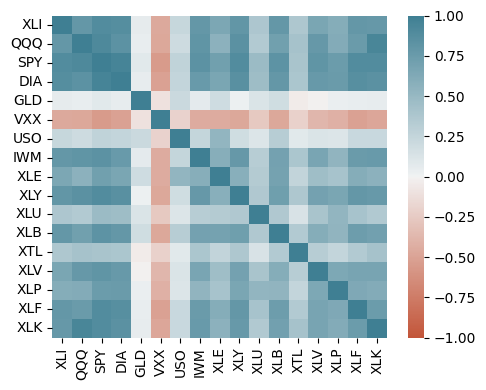

In [41]:
fig, ax = plt.subplots(figsize=(5, 4))
ax = sns.heatmap(etfs.corr(), vmin=-1, vmax=1, 
                 cmap=sns.diverging_palette(20, 220, as_cmap=True),
                 ax=ax)

plt.tight_layout()
plt.show()

The above heatmap works when you have color. For the greyscale images, as used in the book, we need to visualize the direction as well. The following code shows the strength of the correlation using ellipses.

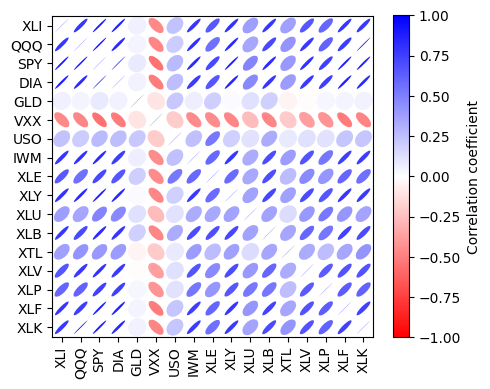

In [42]:
from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize

def plot_corr_ellipses(data, figsize=None, **kwargs):
    ''' https://stackoverflow.com/a/34558488 '''
    M = np.array(data)
    if not M.ndim == 2:
        raise ValueError('data must be a 2D array')
    fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'aspect':'equal'})
    ax.set_xlim(-0.5, M.shape[1] - 0.5)
    ax.set_ylim(-0.5, M.shape[0] - 0.5)
    ax.invert_yaxis()

    # xy locations of each ellipse center
    xy = np.indices(M.shape)[::-1].reshape(2, -1).T

    # set the relative sizes of the major/minor axes according to the strength of
    # the positive/negative correlation
    w = np.ones_like(M).ravel() + 0.01
    h = 1 - np.abs(M).ravel() - 0.01
    a = 45 * np.sign(M).ravel()

    ec = EllipseCollection(widths=w, heights=h, angles=a, units='x', offsets=xy,
                           norm=Normalize(vmin=-1, vmax=1),
                           transOffset=ax.transData, array=M.ravel(), **kwargs)
    ax.add_collection(ec)

    # if data is a DataFrame, use the row/column names as tick labels
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(M.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(data.index)

    return ec, ax

m, ax = plot_corr_ellipses(etfs.corr(), figsize=(5, 4), cmap='bwr_r')
cb = plt.colorbar(m, ax=ax)
cb.set_label('Correlation coefficient')

plt.tight_layout()
plt.show()

### R
R computes the correlation matrix with `cor` and visualizes it with ellipses via `corrplot`.

In [43]:
%%R
telecom <- sp500_px[, sp500_sym[sp500_sym$sector == 'telecommunications_services', 'symbol']]
telecom <- telecom[row.names(telecom) > '2012-07-01',]
telecom_cor <- cor(telecom)

Next we focus on funds traded on major exchanges (sector == 'etf'). 

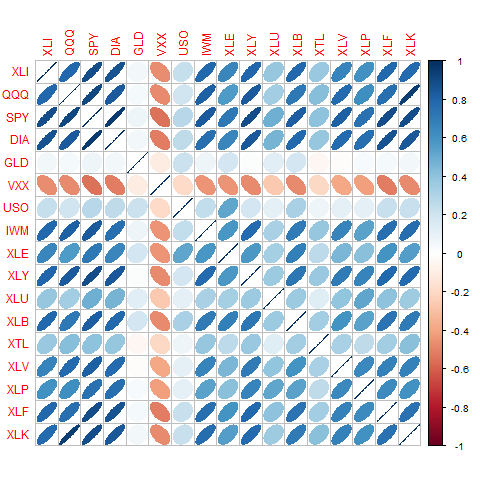

In [44]:
%%R
etfs <- sp500_px[row.names(sp500_px) > '2012-07-01', 
                 sp500_sym[sp500_sym$sector == 'etf', 'symbol']]
corrplot(cor(etfs), method='ellipse')

### Summary: Correlation

| Operation | Python | R | Notes |
|---|---|---|---|
| Sector selection | `DataFrame` filtering | data-frame indexing | Both rely on conditional filtering. |
| Correlation matrix | `DataFrame.corr()` | `cor()` | Numeric output is directly comparable. |
| Correlation visualization | `sns.heatmap()`, custom ellipses | `corrplot(method='ellipse')` | R provides ready-made ellipse plots without custom code. |

Python provides high visualization flexibility at the cost of more helper code. R offers a faster path to classic correlation plots.


## Scatterplots


### Python
Simple scatterplots are supported by _pandas_. Specifying the marker as `$\u25EF$` uses an open circle for each point.

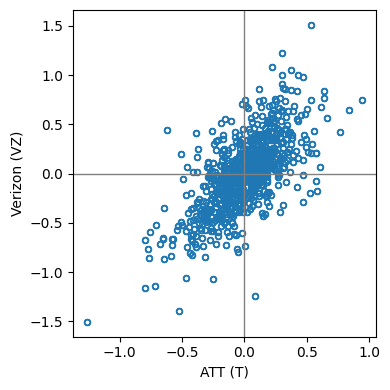

In [45]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

plt.tight_layout()
plt.show()

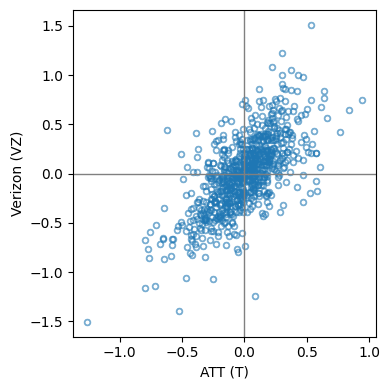

In [46]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$', alpha=0.5)
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

plt.tight_layout()
plt.show()

### R
R builds a scatter plot for two variables and adds reference lines via `abline`.

[1] 754   5


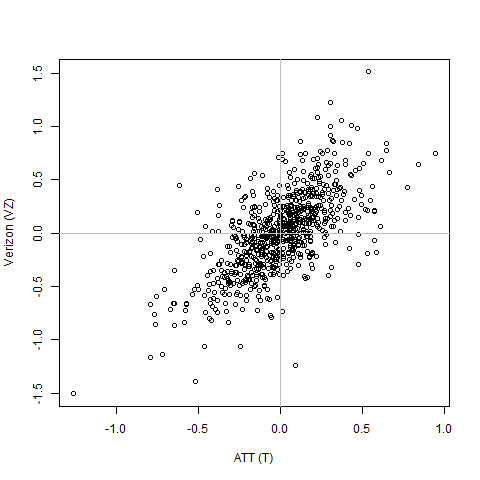

In [47]:
%%R
# plot(telecom$T, telecom$VZ, xlab='T', ylab='VZ', cex=.8)
plot(telecom$T, telecom$VZ, xlab='ATT (T)', ylab='Verizon (VZ)')
abline(h=0, v=0, col='grey')
dim(telecom)

### Summary: Scatterplots

| Operation | Python | R | Notes |
|---|---|---|---|
| Scatter plot | `plot.scatter()` | `plot()` | Both tools support two-variable analysis well. |
| Reference lines | `axhline()`, `axvline()` | `abline(h=..., v=...)` | R uses one function for both lines. |
| Point transparency | `alpha=` | `col`/point parameters | Python has a direct `alpha` argument. |

Python makes small aesthetic tweaks easy through the axes-object API, while R remains syntax-efficient. The analytical outcome is the same: quick insight into dependence.


# Exploring Two or More Variables
Load the kc_tax dataset and filter based on a variety of criteria

### Python

In [48]:
kc_tax = pd.read_csv(KC_TAX_CSV)
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) & 
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

(432693, 3)


### R
R filters data with `subset`, giving concise syntax for multiple logical conditions.

In [49]:
%%R
kc_tax0 <- subset(kc_tax, TaxAssessedValue < 750000 & 
                  SqFtTotLiving > 100 &
                  SqFtTotLiving < 3500)
nrow(kc_tax0)

[1] 432693


### Summary: Exploring Two or More Variables

| Operation | Python | R | Notes |
|---|---|---|---|
| Data loading | `pd.read_csv()` | `read.csv()` | The basic operation is analogous. |
| Multi-criteria filtering | `df.loc[(...) & (...)]` | `subset(... & ...)` | R has very compact `subset` syntax. |
| Size after filtering | `DataFrame.shape` | `nrow()` | Python returns `(rows, columns)`, while R usually returns rows separately. |

Python emphasizes explicit logical operations on columns, while R enables more declarative filtering. In both cases, data preparation is key before 2D visualization.


## Hexagonal binning and Contours 
### Plotting numeric versus numeric data

### Python
If the number of data points gets large, scatter plots will no longer be meaningful. Here methods that visualize densities are more useful. The `hexbin` method for _pandas_ data frames is one powerful approach.

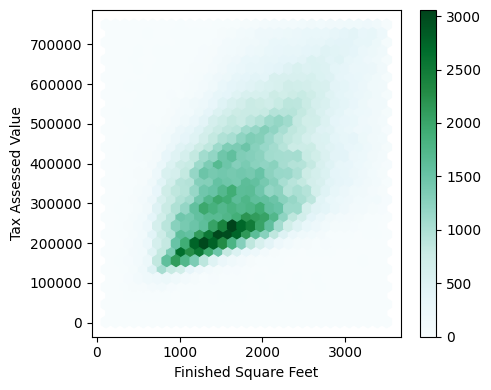

In [50]:
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

The _seaborn_ kdeplot is a two-dimensional extension of the density plot. The calculation of the 2D-density for the full dataset takes several minutes. It is sufficient to create the visualization with a smaller sample of the dataset. With 10,000 data points, creating the graph takes only seconds. While some details may be lost, the overall shape is preserved. 

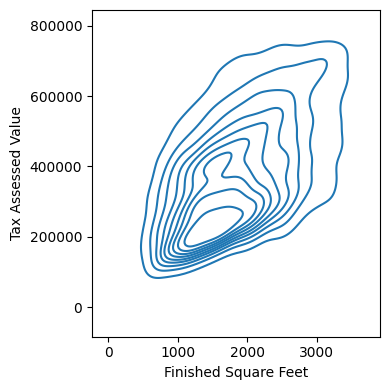

In [51]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000), x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

### R
If the number of data points gets large, scatter plots will no longer be meaningful. Here methods that visualize densities are more useful. The `stat_hexbin` method for is one powerful approach.

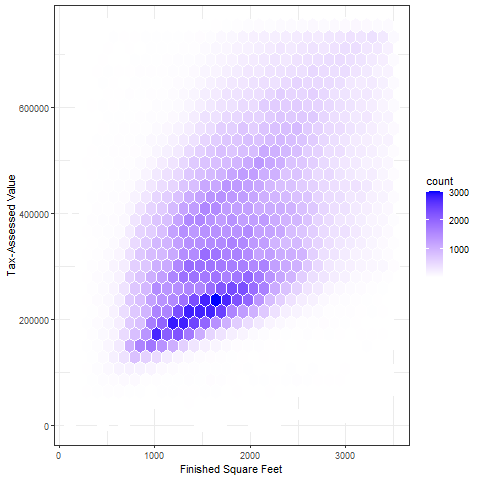

In [52]:
%%R

graph <- ggplot(kc_tax0, (aes(x=SqFtTotLiving, y=TaxAssessedValue))) + 
  stat_binhex(color='white') + 
  theme_bw() + 
  scale_fill_gradient(low='white', high='blue') +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE)) +
  labs(x='Finished Square Feet', y='Tax-Assessed Value')
graph

Visualize as a two-dimensional extension of the density plot. 

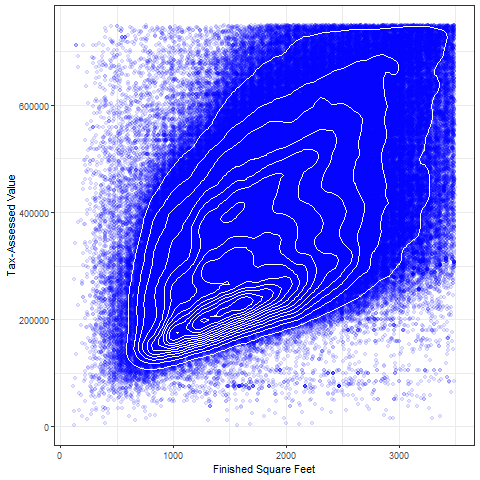

In [53]:
%%R
graph <- ggplot(kc_tax0, aes(SqFtTotLiving, TaxAssessedValue)) +
  theme_bw() + 
  geom_point(color='blue', alpha=0.1) + 
  geom_density2d(color='white') + 
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE)) +
  labs(x='Finished Square Feet', y='Tax-Assessed Value')
graph

### Summary: Hexagonal Binning and Contours

| Operation | Python | R | Notes |
|---|---|---|---|
| Hexbin | `plot.hexbin()` | `stat_binhex()` | Both methods reduce overplotting effectively. |
| KDE 2D | `sns.kdeplot(x=..., y=...)` | `geom_density2d()` | Python uses direct KDE estimation, while R often overlays contour lines. |
| Data sample | `sample(10000)` | full set/subset in `ggplot` | Python explicitly demonstrates sampling for performance. |

Python often requires explicit thinking about computational cost (e.g., sampling), while R conveniently layers plots in `ggplot2`. Both approaches reveal density structure effectively.


## Two Categorical Variables
Load the `lc_loans` dataset

### Python

In [54]:
lc_loans = pd.read_csv(LC_LOANS_CSV)

In [55]:
# Table 1-8(1)
crosstab = lc_loans.pivot_table(index='grade', columns='status', 
                                aggfunc=lambda x: len(x), margins=True)
print(crosstab)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961


In [56]:
# Table 1-8(2)
df = crosstab.copy().loc['A':'G',:].astype(float)
df.loc[:,'Charged Off':'Late'] = df.loc[:,'Charged Off':'Late'].div(df['All'], axis=0)
df['All'] = df['All'] / sum(df['All'])
perc_crosstab = df
print(perc_crosstab)

status  Charged Off   Current  Fully Paid      Late       All
grade                                                        
A          0.021548  0.690454    0.281528  0.006470  0.160746
B          0.040054  0.709013    0.235401  0.015532  0.293529
C          0.049828  0.735702    0.191495  0.022974  0.268039
D          0.067410  0.717328    0.184189  0.031073  0.164708
E          0.081657  0.707936    0.170929  0.039478  0.077177
F          0.118258  0.654371    0.180409  0.046962  0.028614
G          0.126196  0.614008    0.198396  0.061401  0.007187


### R
R creates a cross-tabulation for categorical variables using `CrossTable` from `gmodels`.

In [57]:
%%R
x_tab <- CrossTable(lc_loans$grade, lc_loans$status, 
                    prop.c=FALSE, prop.chisq=FALSE, prop.t=FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|-------------------------|

 
Total Observations in Table:  450961 

 
               | lc_loans$status 
lc_loans$grade | Charged Off |     Current |  Fully Paid |        Late |   Row Total | 
---------------|-------------|-------------|-------------|-------------|-------------|
             A |        1562 |       50051 |       20408 |         469 |       72490 | 
               |       0.022 |       0.690 |       0.282 |       0.006 |       0.161 | 
---------------|-------------|-------------|-------------|-------------|-------------|
             B |        5302 |       93852 |       31160 |        2056 |      132370 | 
               |       0.040 |       0.709 |       0.235 |       0.016 |       0.294 | 
---------------|-------------|-------------|-------------|-------------|-------------|
             C |        6023 |       88928 |       23147 |        2777 |      120875 | 
 

### Summary: Two Categorical Variables

| Operation | Python | R | Notes |
|---|---|---|---|
| Cross-tabulation | `pivot_table(..., aggfunc=len)` | `CrossTable()` | R immediately provides richer descriptive statistics. |
| Row proportions | divide columns by `All` | `CrossTable` options | Python gives full control over normalization strategy. |
| Aggregate table | `margins=True` | totals/table options | Both support global-share analysis. |

Python favors manual percentage transformations, which can be more transparent. R delivers an analysis-ready table faster via specialized functions.


## Categorical and Numeric Data


### Python
_Pandas_ boxplots of a column can be grouped by a different column.

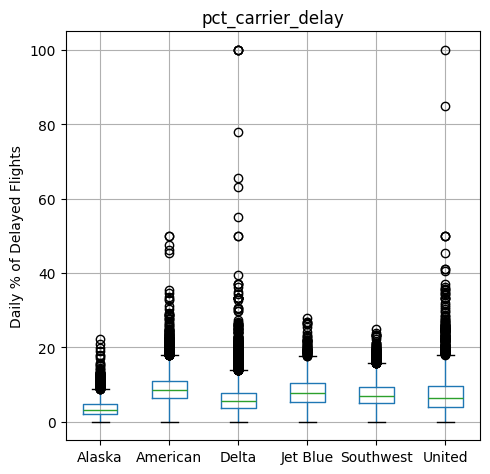

In [58]:
airline_stats = pd.read_csv(AIRLINE_STATS_CSV)
airline_stats.head()
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay',
                           figsize=(5, 5))
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')
plt.suptitle('')

plt.tight_layout()
plt.show()

_Pandas_ also supports a variation of boxplots called _violinplot_. 

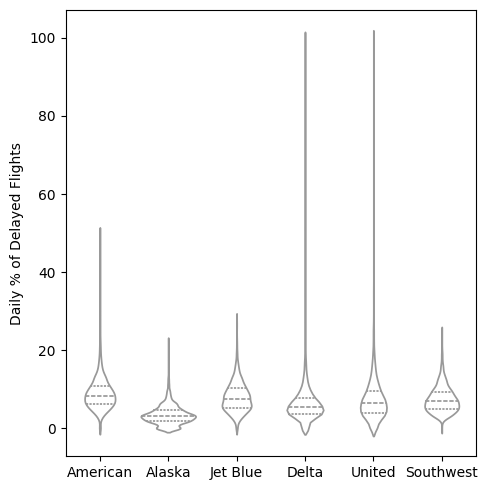

In [59]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               ax=ax, inner='quartile', color='white')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

plt.tight_layout()
plt.show()

### R
R shows the relationship between a categorical and numeric variable using a boxplot and a violin-plot variant.

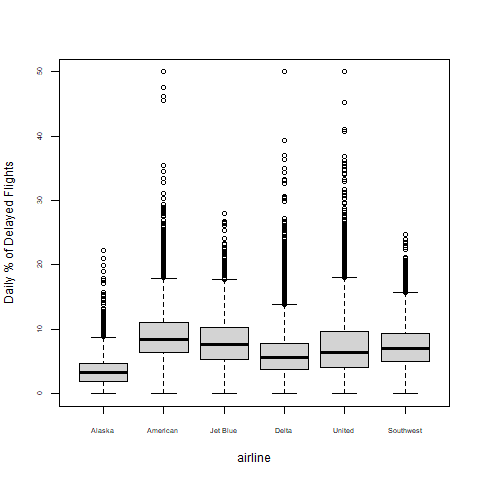

In [60]:
%%R
boxplot(pct_carrier_delay ~ airline, data=airline_stats, ylim=c(0, 50), 
        cex.axis=.6, ylab='Daily % of Delayed Flights')

Variation of boxplots called _violinplot_. 

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: Removed 28 rows containing non-finite outside the scale range (`stat_ydensity()`). 
  
R callback write-console: 2: Removed 28 rows containing non-finite outside the scale range (`stat_ydensity()`). 
  


In addition: Warning message:
The `draw_quantiles` argument of `geom_violin()` is deprecated as of ggplot2 4.0.0.
i Please use the `quantiles.linetype` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 


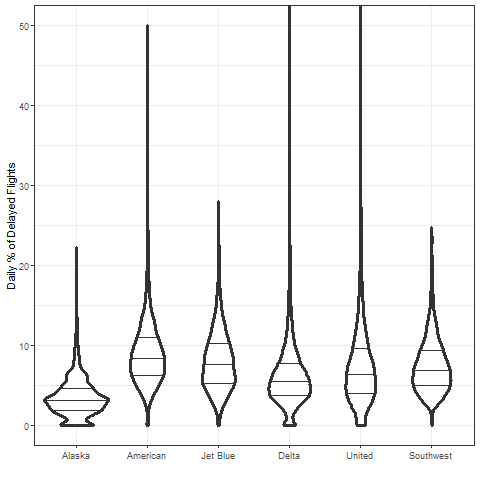

In [61]:
%%R
graph <- ggplot(data=airline_stats, aes(airline, pct_carrier_delay)) + 
  geom_violin(draw_quantiles = c(.25,.5,.75), linetype=2) +
  geom_violin(fill=NA, linewidth=1.1) +
  coord_cartesian(ylim=c(0, 50)) +
  labs(x='', y='Daily % of Delayed Flights') +
  theme_bw()
graph

### Summary: Categorical and Numeric Data

| Operation | Python | R | Notes |
|---|---|---|---|
| Grouped boxplot | `DataFrame.boxplot(by=...)` | `boxplot(y ~ x, data=...)` | Both languages support comparing distributions across categories. |
| Violinplot | `sns.violinplot()` | `geom_violin()` | `ggplot2` provides layered styling control. |
| Axis labels and range | `ax.*` methods | `labs()`, `coord_cartesian()` | Python more often configures parameters after plot creation. |

R/`ggplot2` naturally leads to a layered declarative syntax, while Python mixes object-oriented style (`matplotlib`) with `seaborn` convenience. For EDA, both approaches are equally effective.


## Visualizing Multiple Variables

### Python

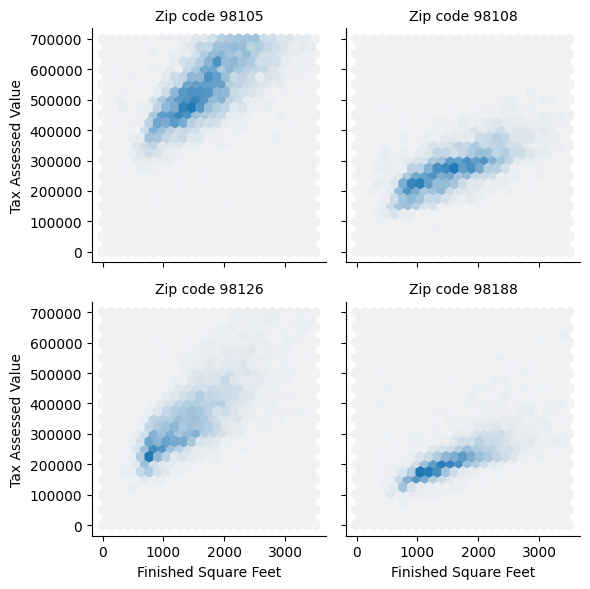

In [62]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes),:]
kc_tax_zip

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue', 
      extent=[0, 3500, 0, 700000])
g.set_axis_labels('Finished Square Feet', 'Tax Assessed Value')
g.set_titles('Zip code {col_name:.0f}')

plt.tight_layout()
plt.show()

### R
R uses `facet_wrap` to compare variable relationships across several ZIP codes at once.

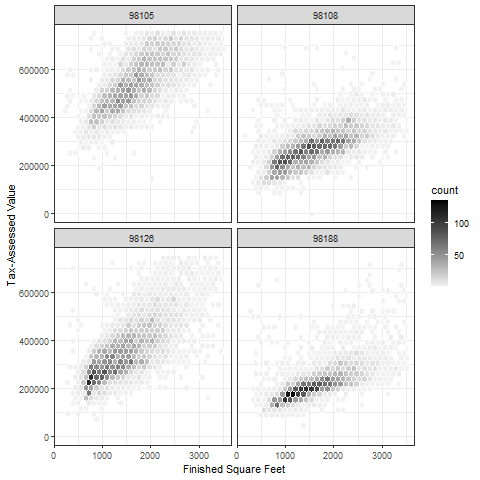

In [63]:
%%R
graph <- ggplot(subset(kc_tax0, ZipCode %in% c(98188, 98105, 98108, 98126)),
                aes(x=SqFtTotLiving, y=TaxAssessedValue)) + 
  stat_binhex(colour='white') + 
  theme_bw() + 
  scale_fill_gradient(low='gray95', high='black') +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE)) +
  labs(x='Finished Square Feet', y='Tax-Assessed Value') +
  facet_wrap('ZipCode')
graph

### Summary: Visualizing Multiple Variables

| Operation | Python | R | Notes |
|---|---|---|---|
| Plot faceting | `sns.FacetGrid(..., col=..., col_wrap=...)` | `facet_wrap('ZipCode')` | Both libraries support small multiples. |
| 2D density plot | `plt.hexbin()` in a mapped function | `stat_binhex()` | Same concept: compare density patterns across panels. |
| Label customization | `set_axis_labels()`, `set_titles()` | `labs()` | R and Python differ in where configuration lives, not in capabilities. |

Python offers high flexibility through panel-mapped functions, while R simplifies faceting with a single declaration. Both scale well for comparative subset analysis.
